# Analysis -- sparse synthetic graphs (complex network)

Reads `results_dp_sbm_sparse_n500.csv` from `script_sparse_synthetic_graph.py`.

n is fixed at 500; the swept axis is the **sparsity regime**:

| regime | p | expected degree |
|---|---|---|
| `relatively_sparse` | log(n)/n | ~ log n (3.4) |
| `sparse` | 5/n | O(1) (2.7) |

Three **private** methods; the thesis version's non-private spectral ceiling
was deliberately removed. Consequence for reading these figures: there is no
non-private reference line, so a low NMI cannot be split into "cost of
privacy" versus "cost of sparsity" from this CSV alone. The `sparse` regime
is only partially recoverable **even with no privacy noise at all** -- a
constant fraction of nodes sit in small components.

Every method is fit on the **largest connected component**; `n_fit` is the
node count actually modelled, `N` stays the nominal draw size.


In [1]:
# -- load results (handles both single-file and sharded output) --------------
import glob
import numpy as np
import pandas as pd

OUTPUT_CSV = "./results/results_dp_sbm_sparse_n5000.csv"   # match OUTPUT_CSV in the driver

shard_files = sorted(glob.glob(f"{OUTPUT_CSV}.shard*"))
if shard_files:
    df = pd.concat([pd.read_csv(f) for f in shard_files], ignore_index=True)
    print(f"Loaded {len(shard_files)} shard files, {len(df)} rows total.")
else:
    df = pd.read_csv(OUTPUT_CSV)
    print(f"Loaded {OUTPUT_CSV}, {len(df)} rows.")

_bad = df.loc[df["epsilon"] > 700, "sigma"].unique()
assert len(_bad) == 0, f"epsilon > 700 at sigma={_bad}: exp() overflowed in edge_flip"

FACET = 'regime'          # the sweep axis besides sigma (None = single panel)
FACETS = sorted(df[FACET].unique()) if FACET else [None]

print()
print("  sigma :", sorted(df["sigma"].unique()))
print("  method:", sorted(df["method"].unique()))
if FACET:
    print(f"  {FACET}:", FACETS)
print("  reps  :", sorted(df.groupby([c for c in ([FACET] if FACET else []) + ["sigma", "method"]]).size().unique()))
df.head()

Loaded ./results/results_dp_sbm_sparse_n5000.csv, 600 rows.

  sigma : [1.0, 2.0, 5.0, 10.0, 20.0]
  method: ['edge_flip_spectral', 'edge_flip_vem', 'sbm_dpsgd_all_noised']
  regime: ['relatively_sparse', 'sparse']
  reps  : [20]


,regime,N,p,q,sigma,epsilon,rep,method,epsilon_gamma,epsilon_beta,...,lcc_frac,n_components,n_isolated,beta_true_00,beta_true_01,beta_true_11,beta_est_00,beta_est_01,beta_est_11,nmi
0,relatively_sparse,5000,0.001703,0.00017,1.0,27.438851,0,edge_flip_vem,NaN,NaN,...,0.9922,39,37,0.001703,0.00017,0.001703,0.000953,0.003427,0.000000,0.000401
1,relatively_sparse,5000,0.001703,0.00017,1.0,27.438851,0,edge_flip_spectral,NaN,NaN,...,0.9922,39,37,0.001703,0.00017,0.001703,0.001743,0.000162,0.001749,0.793494
2,relatively_sparse,5000,0.001703,0.00017,1.0,27.438851,0,sbm_dpsgd_all_noised,26.32774,5.635918,...,0.9922,39,37,0.001703,0.00017,0.001703,0.116713,0.003656,0.108500,0.000018
3,relatively_sparse,5000,0.001703,0.00017,2.0,11.728685,0,edge_flip_vem,NaN,NaN,...,0.9922,39,37,0.001703,0.00017,0.001703,0.000953,0.003419,0.000000,0.000401
4,relatively_sparse,5000,0.001703,0.00017,2.0,11.728685,0,edge_flip_spectral,NaN,NaN,...,0.9922,39,37,0.001703,0.00017,0.001703,0.001747,0.000162,0.001747,0.780850


## Coverage


In [2]:
# -- which cells are complete? ------------------------------------------------
keys = ([FACET] if FACET else []) + ["sigma", "method"]
counts = df.groupby(keys).size().unstack("method").fillna(0).astype(int)
expected = int(counts.values.max()) if counts.size else 0
print(f"expected reps per cell (max seen): {expected}\n")
print(counts.to_string())
missing = counts[(counts < expected).any(axis=1)]
print("\nINCOMPLETE cells:\n" + missing.to_string() if len(missing) else "\nAll cells complete.")

# epochs is written for edge_flip_vem and sbm_dpsgd only -- spectral has no
# iterative epoch to count, so its blank column is expected, not a gap.
print("\nnon-null `epochs` by method:")
print(df.groupby("method")["epochs"].apply(lambda s: f"{s.notna().sum()}/{len(s)}").to_string())

print("\ndistinct epsilon per sigma (must all be 1):")
print(df.groupby("sigma")["epsilon"].nunique().to_string())

expected reps per cell (max seen): 20

method                   edge_flip_spectral  edge_flip_vem  sbm_dpsgd_all_noised
regime            sigma                                                         
relatively_sparse 1.0                    20             20                    20
                  2.0                    20             20                    20
                  5.0                    20             20                    20
                  10.0                   20             20                    20
                  20.0                   20             20                    20
sparse            1.0                    20             20                    20
                  2.0                    20             20                    20
                  5.0                    20             20                    20
                  10.0                   20             20                    20
                  20.0                   20             20            

## NMI


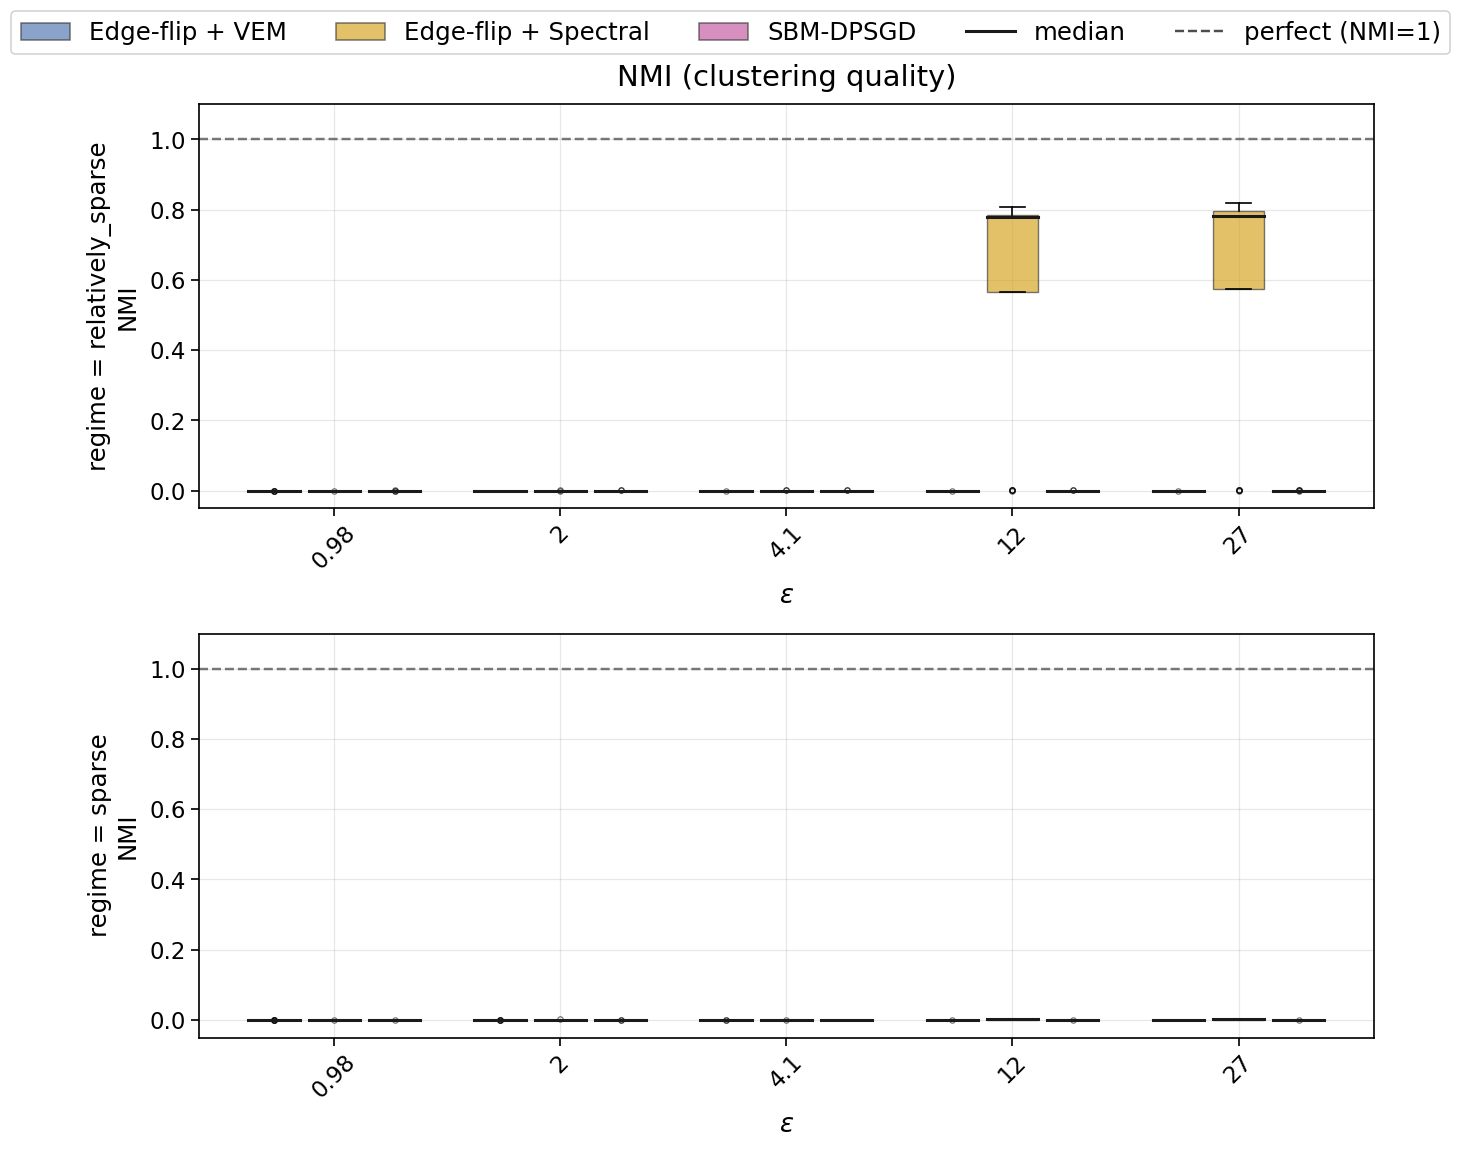

In [3]:
# -- Boxplots of NMI vs epsilon ----------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from plot_style import (apply_style, figsize, grouped_boxplot, method_color,
                        method_label, order_methods, reference_line,
                        BOX_ALPHA, MEDIAN_COLOR, REFERENCE_COLOR)

apply_style()
methods = order_methods(df["method"].unique())
PANEL_W, PANEL_H = 9.0, 3.9

fig, axes = plt.subplots(len(FACETS), 1,
                         figsize=figsize(PANEL_W, PANEL_H * len(FACETS)), squeeze=False)
for row, fv in enumerate(FACETS):
    ax = axes[row, 0]
    sub = df[df[FACET] == fv].dropna(subset=["nmi"])
    grouped_boxplot(ax, sub, "nmi", methods=methods)
    reference_line(ax, 1.0)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(f"{FACET} = {fv}\nNMI", fontsize=16)
    if row == 0:
        ax.set_title('NMI (clustering quality)', fontsize=19, pad=12)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
            Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
                   label="perfect (NMI=1)")]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.005))
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig('figures/nmi_sparse_n500.png', dpi=200, bbox_inches="tight")
plt.show()

### Per-rep spread

Graphs are resampled per rep here, so spread mixes graph randomness with
DP-mechanism randomness -- unlike the polblogs notebook, where the graph is
fixed.


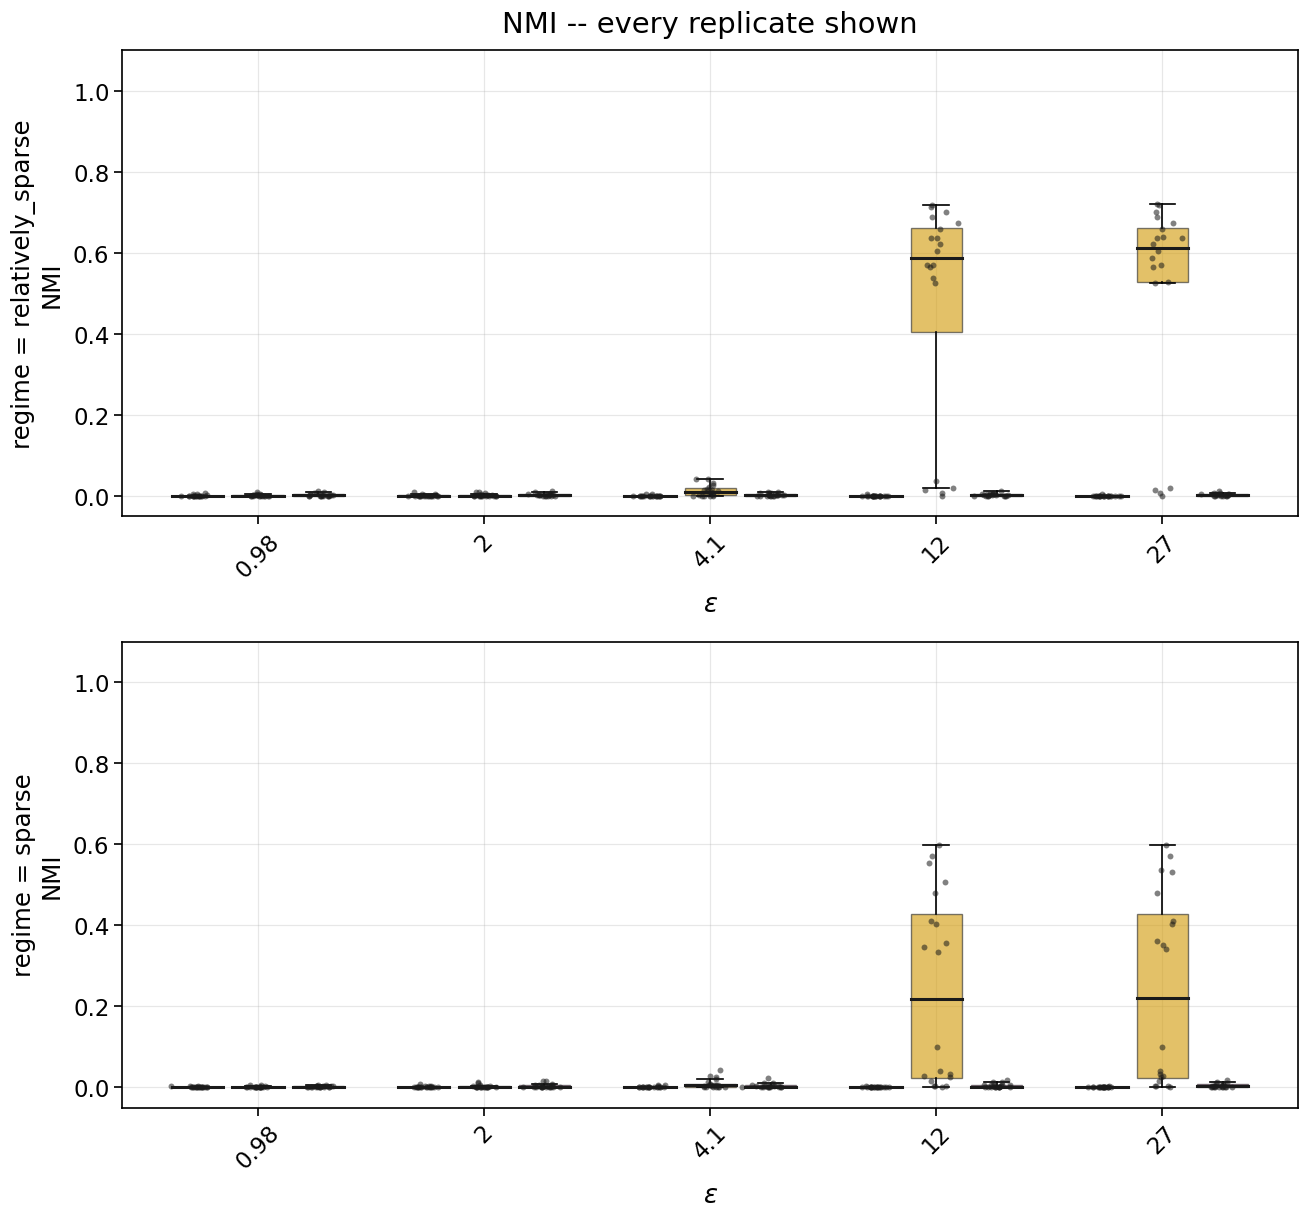

mean NMI  (collapse rate in brackets)

method                  edge_flip_spectral  edge_flip_vem sbm_dpsgd_all_noised
regime            sigma                                                       
relatively_sparse 1.0         0.506  (0.2)    0.0  (0.95)        0.004  (0.15)
                  2.0        0.475  (0.25)    0.0  (0.95)         0.003  (0.2)
                  5.0         0.014  (1.0)     0.0  (0.9)         0.004  (0.3)
                  10.0        0.003  (1.0)   0.001  (0.6)         0.004  (0.2)
                  20.0        0.002  (1.0)   0.001  (0.7)        0.003  (0.35)
sparse            1.0         0.242  (0.5)    0.0  (0.95)         0.004  (0.3)
                  2.0          0.24  (0.5)    0.0  (0.95)         0.004  (0.2)
                  5.0         0.009  (1.0)  0.001  (0.85)        0.004  (0.45)
                  10.0        0.003  (1.0)   0.001  (0.6)        0.003  (0.55)
                  20.0        0.001  (1.0)   0.001  (0.8)         0.002  (0.4)

thresholds: 

In [5]:
# -- every rep, jittered over the box ----------------------------------------
from plot_style import box_positions

apply_style()
rng = np.random.default_rng(0)
eps_vals = sorted(df["epsilon"].unique())

fig, axes = plt.subplots(len(FACETS), 1,
                         figsize=figsize(9.0, 4.2 * len(FACETS)), squeeze=False)
for row, fv in enumerate(FACETS):
    ax = axes[row, 0]
    sub = (df if fv is None else df[df[FACET] == fv]).dropna(subset=["nmi"])
    grouped_boxplot(ax, sub, "nmi", methods=methods, showfliers=False)
    pos_map, width = box_positions(methods, eps_vals)
    for ev in eps_vals:
        for m in methods:
            v = sub.loc[(sub["epsilon"] == ev) & (sub["method"] == m), "nmi"].values
            if len(v) == 0:
                continue
            ax.scatter(pos_map[(ev, m)] + rng.normal(0, width * 0.12, len(v)), v,
                       s=15, color="#1A1A1A", alpha=0.55, zorder=4, linewidths=0)
    ax.set_ylim(-0.05, 1.1)
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(("NMI" if fv is None else f"{FACET} = {fv}\nNMI"), fontsize=16)
    if row == 0:
        ax.set_title("NMI -- every replicate shown", fontsize=19, pad=12)
plt.tight_layout()
plt.show()

# Collapse rate: fraction of reps below 20% of that method's OWN best cell mean.
# Relative, not absolute, because the achievable NMI differs hugely between
# these settings -- an absolute 0.15 cutoff would be meaningless in a regime
# where nothing exceeds 0.3.
keys = ([FACET] if FACET else []) + ["sigma"]
thresh = {m: 0.2 * df[df.method == m].groupby(keys)["nmi"].mean().max()
          for m in df["method"].unique()}
coll = (df.assign(fail=df.apply(lambda r: r["nmi"] < thresh[r["method"]], axis=1))
          .groupby(keys + ["method"])["fail"].mean().unstack("method").round(2))
mean_tbl = df.pivot_table(index=keys, columns="method", values="nmi", aggfunc="mean").round(3)
print("mean NMI  (collapse rate in brackets)\n")
print((mean_tbl.astype(str) + "  (" + coll.astype(str) + ")").to_string())
print("\nthresholds:", {k: round(v, 4) for k, v in thresh.items()})

flag = [(i, m) for m in coll.columns for i, v in coll[m].items()
        if v == v and 0.15 < v < 0.85]
if flag:
    print("\nBIMODAL cells -- means are not descriptive, use the scatter above:")
    for i, m in flag:
        print(f"  {i}  {m:<22} mean={mean_tbl.loc[i, m]:.3f}  collapse={coll.loc[i, m]:.2f}")
else:
    print("\nNo bimodal cells detected.")

## Is `edge_flip_spectral` measuring privacy?

At mean degree 2.7-3.4 these graphs are exactly where plain spectral
clustering degenerates, so this check matters here.


In [4]:
# -- IS edge_flip_spectral MEASURING PRIVACY, OR REGULARIZATION? --------------
# Established on polblogs: edge-flip adds p_flip*(N-1) random edges per node,
# which acts as the tau/N regularization that sparse / degree-heterogeneous
# spectral clustering needs (Amini et al. 2013; Qin & Rohe 2013).  That makes
# NMI a REGULARIZATION curve with an interior optimum, not a monotone privacy
# curve: too little noise leaves the degenerate cut in place, too much buries
# the signal.
#
# Signature to look for: edge_flip_spectral peaking at an INTERIOR epsilon
# rather than at the largest one.  If that happens here, the number at the
# peak is not "our DP method is good" -- it is "the DP noise happened to
# regularize a baseline that was broken without it".
#
# mean_degree here is of the drawn graph (pre-LCC where an LCC is taken), so
# tau_eff/mean_deg is approximate -- it is a diagnostic, not an estimate.
mdeg = df.groupby([c for c in ([FACET] if FACET else [])] + ["epsilon"])["mean_degree"].mean()

rows = []
for keyvals, g in df[df.method == "edge_flip_spectral"].groupby(
        [c for c in ([FACET] if FACET else [])] + ["epsilon"]):
    eps = keyvals[-1] if isinstance(keyvals, tuple) else keyvals
    p = 1.0 / (1.0 + np.exp(eps))
    n = int(g["n_fit"].iloc[0]) if "n_fit" in g else int(g["N"].iloc[0])
    md_ = mdeg.loc[keyvals]
    rows.append({(FACET or "_"): (keyvals[0] if FACET else "all"), "epsilon": round(eps, 3),
                 "p_flip": p, "added_deg": p * (n - 1),
                 "tau_eff/mean_deg": p * (n - 1) / md_ if md_ > 0 else np.nan,
                 "nmi_mean": g["nmi"].mean()})
reg = pd.DataFrame(rows).set_index([(FACET or "_"), "epsilon"]).sort_index()
print(reg.round(4).to_string())

print("\n-- non-monotonicity check (edge_flip_spectral) --")
# MARGIN guards against a false positive when the curve is saturated: with
# several cells tied at 1.0, idxmax returns the FIRST of them, which looks
# like an interior optimum but is a tie.  Only a peak that beats the
# largest-epsilon value by more than MARGIN is a real interior optimum.
MARGIN = 0.02
flagged = False
for f in ([*FACETS] if FACET else ["all"]):
    sub = reg.loc[f].sort_index()
    eps_max = sub.index.max()
    at_max = sub["nmi_mean"].loc[eps_max]
    peak_eps, peak = sub["nmi_mean"].idxmax(), sub["nmi_mean"].max()
    if peak - at_max > MARGIN:
        flagged = True
        print(f"  {f}: peak NMI {peak:.4f} at epsilon={peak_eps}, but only "
              f"{at_max:.4f} at the LARGEST epsilon={eps_max:.3f}  "
              f"(gap {peak - at_max:+.4f})")
        print(f"      -> INTERIOR OPTIMUM: regularization artifact, not a privacy result.")
    elif peak_eps != eps_max:
        print(f"  {f}: peak at epsilon={peak_eps} but only {peak - at_max:+.4f} above "
              f"the largest epsilon -- a tie, not an interior optimum "
              f"(both {at_max:.4f}).")
    else:
        print(f"  {f}: monotone in epsilon (peak at the largest epsilon) -- as expected.")
if flagged:
    print("\n  Sanity check to run: fit plain spectral clustering on the TRUE")
    print("  adjacency (no flipping).  If it also scores near the largest-epsilon")
    print("  value, the baseline -- not privacy -- is what is limiting the method.")

                           p_flip  added_deg  tau_eff/mean_deg  nmi_mean
regime            epsilon                                               
relatively_sparse 0.977    0.2734   129.8697           37.5368    0.0019
                  1.995    0.1198    56.8915           16.4436    0.0025
                  4.148    0.0155     7.3831            2.1340    0.0136
                  11.729   0.0000     0.0038            0.0011    0.4754
                  27.439   0.0000     0.0000            0.0000    0.5061
sparse            0.977    0.2734   127.9558           46.6311    0.0011
                  1.995    0.1198    56.0531           20.4275    0.0026
                  4.148    0.0155     7.2743            2.6510    0.0087
                  11.729   0.0000     0.0038            0.0014    0.2403
                  27.439   0.0000     0.0000            0.0000    0.2416

-- non-monotonicity check (edge_flip_spectral) --
  relatively_sparse: monotone in epsilon (peak at the largest epsilon) --

## Estimated beta

Reference is the **nominal** planted p and q. Intra and inter are on
separate scales -- they differ by 10x.


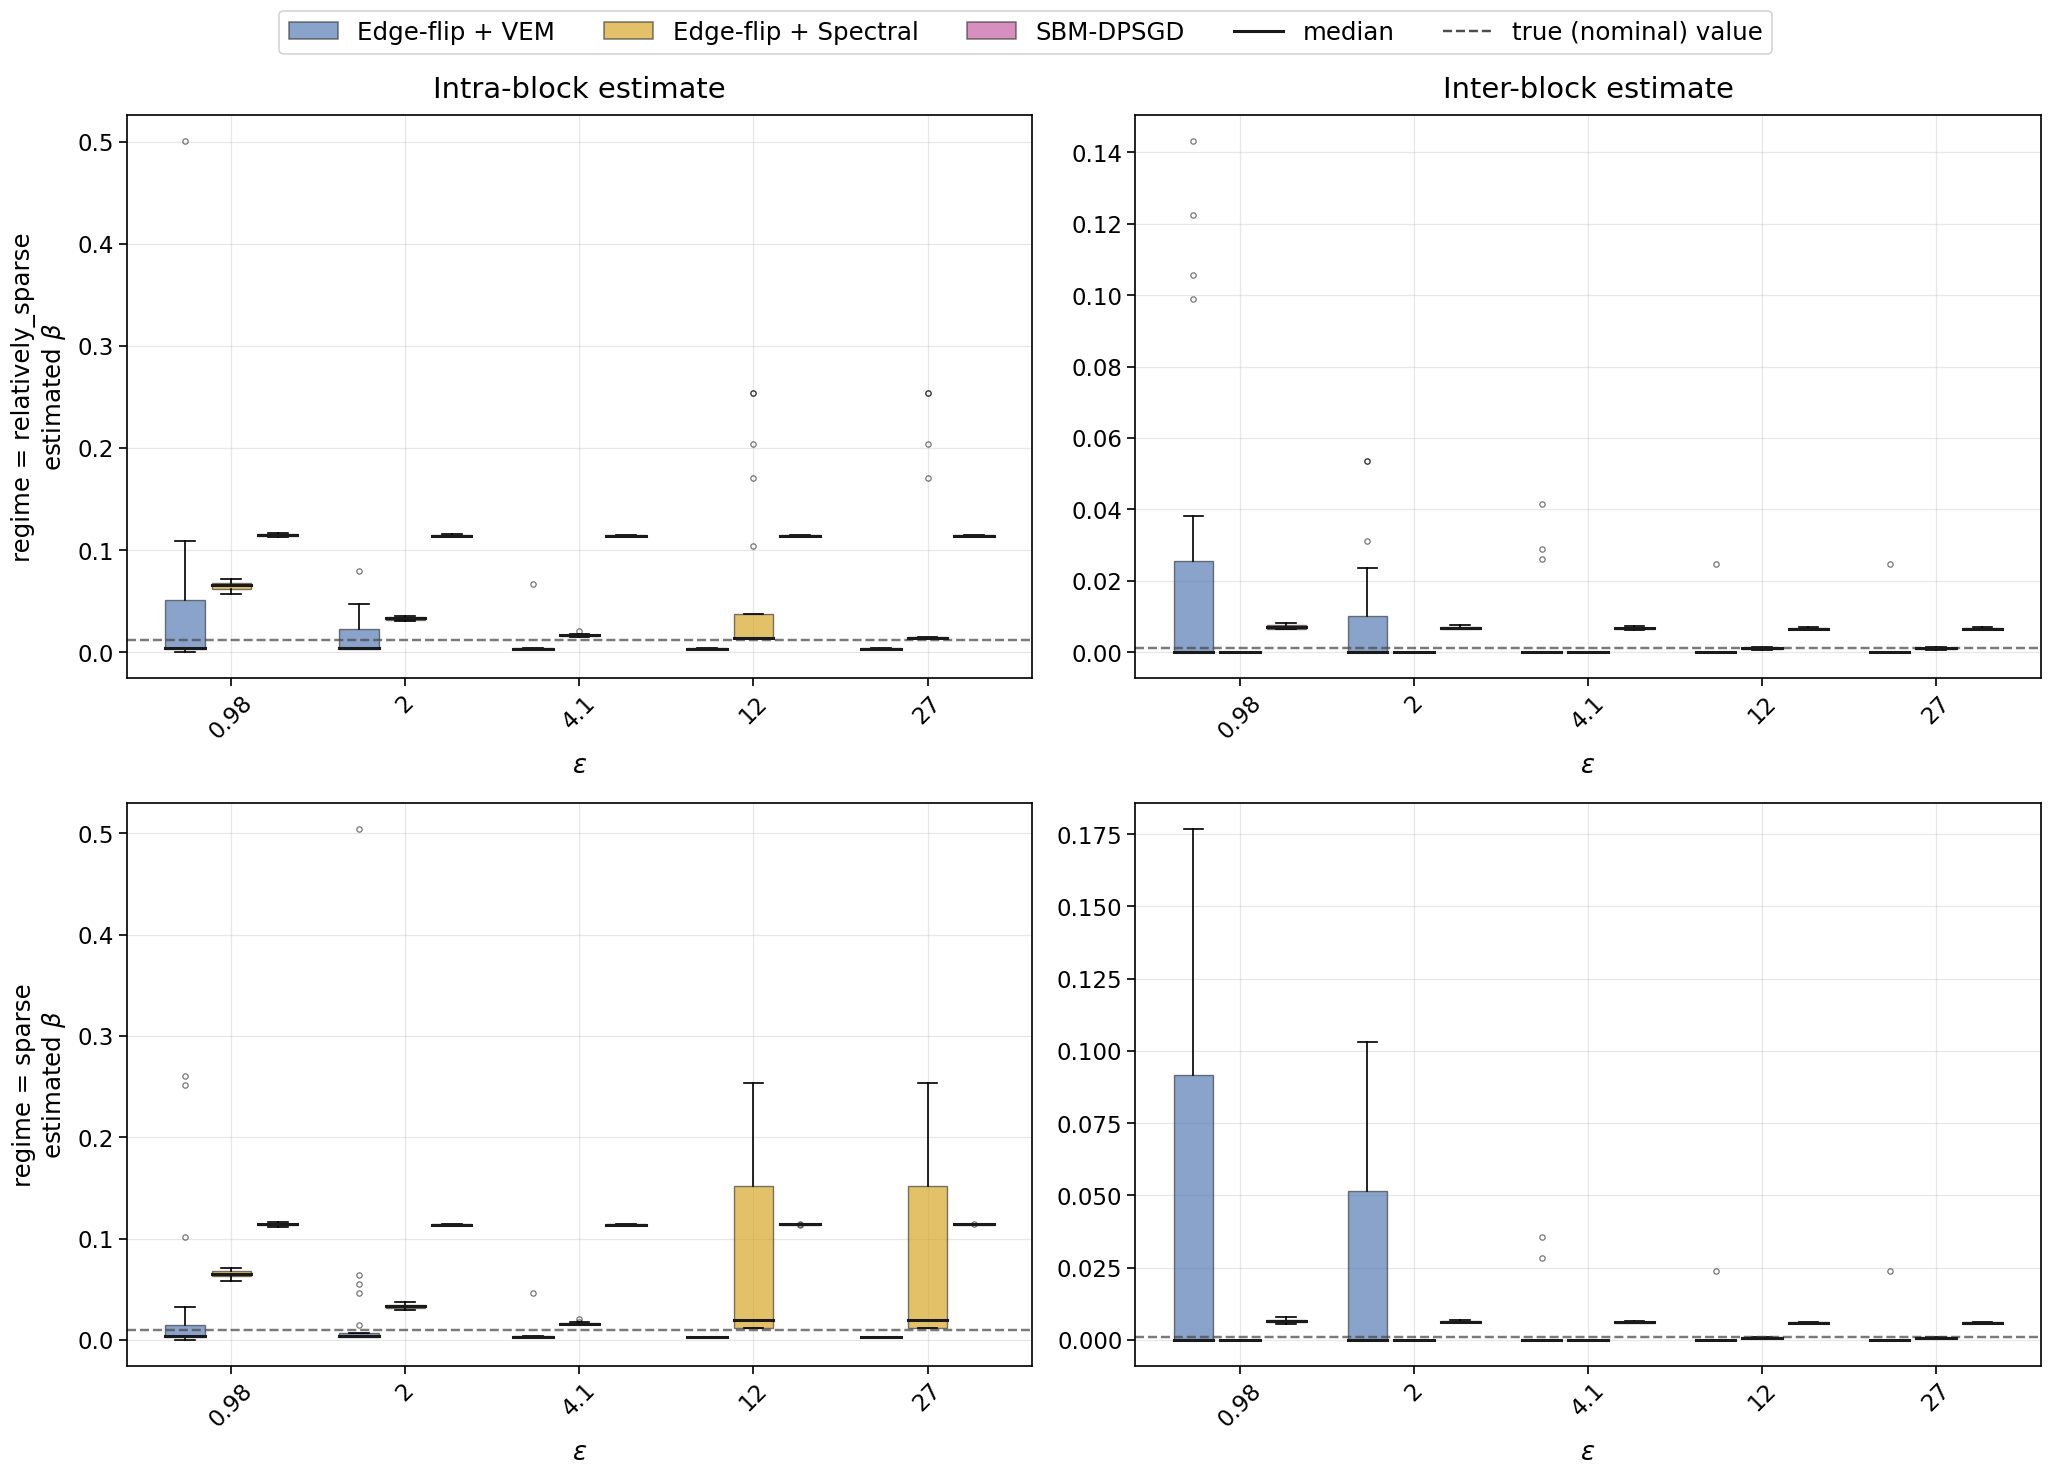

nominal p / q by regime:
                          p         q  beta_true_00  beta_true_01
regime                                                           
relatively_sparse  0.012429  0.001243      0.012429      0.001243
sparse             0.010000  0.001000      0.010000      0.001000

CAVEAT: beta estimates are only meaningful where the LABELS are right.
Where NMI ~ 0 they describe an arbitrary 2-partition, not the blocks.


In [6]:
# -- Boxplots of estimated beta vs epsilon -----------------------------------
apply_style()
df["intra_est"] = df[["beta_est_00", "beta_est_11"]].mean(axis=1)
fig, axes = plt.subplots(len(FACETS), 2, figsize=figsize(14.0, 5.0 * len(FACETS)), squeeze=False)

for row, fv in enumerate(FACETS):
    sub = df[df[FACET] == fv]
    for col, (est, tru, title) in enumerate([
            ("intra_est", "beta_true_00", "Intra-block estimate"),
            ("beta_est_01", "beta_true_01", "Inter-block estimate")]):
        ax = axes[row, col]
        grouped_boxplot(ax, sub, est, methods=methods)
        reference_line(ax, sub[tru].iloc[0])
        ax.set_xlabel(r"$\epsilon$")
        if row == 0:
            ax.set_title(title, fontsize=19, pad=12)
    axes[row, 0].set_ylabel(f"{FACET} = {fv}\n" r"estimated $\beta$", fontsize=16)

handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods]
handles += [Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median"),
            Line2D([0], [0], color=REFERENCE_COLOR, linestyle="--", linewidth=1.6,
                   label="true (nominal) value")]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.005))
plt.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig("figures/beta_sparse_n500.png", dpi=200, bbox_inches="tight")
plt.show()

print("nominal p / q by regime:")
print(df.groupby(FACET)[["p", "q", "beta_true_00", "beta_true_01"]].first().to_string())
print("\nCAVEAT: beta estimates are only meaningful where the LABELS are right.")
print("Where NMI ~ 0 they describe an arbitrary 2-partition, not the blocks.")

## Graph fragmentation

How much of each draw the fit actually covered. Nothing branches on these --
they are recorded so the LCC restriction is visible rather than implicit.


In [7]:
# -- what the LCC restriction cost --------------------------------------------
g = (df.groupby(FACET)
       .agg(N_nominal=("N", "first"), n_fit=("n_fit", "mean"),
            lcc_frac=("lcc_frac", "mean"), mean_degree=("mean_degree", "mean"),
            n_components=("n_components", "mean"), n_isolated=("n_isolated", "mean"))
       .round(2))
print(g.to_string())
print("\nlcc_frac well below 1 means the reported NMI is scored on a SUBSET of")
print("the drawn graph -- the discarded nodes are mostly isolated vertices that")
print("carry no signal for any method, but the node set is not the full draw.")

                   N_nominal   n_fit  lcc_frac  mean_degree  n_components  n_isolated
regime                                                                               
relatively_sparse        500  481.25      0.96         3.46         18.50       16.65
sparse                   500  462.25      0.92         2.74         33.75       29.10

lcc_frac well below 1 means the reported NMI is scored on a SUBSET of
the drawn graph -- the discarded nodes are mostly isolated vertices that
carry no signal for any method, but the node set is not the full draw.


## Compute cost (epochs)


In [ ]:
# -- Boxplots of # epochs vs epsilon -----------------------------------------
# NOT wall-clock comparable across methods: a VEM epoch is a dense O(N^2)
# matmul pass, an SBM-DPSGD epoch a sampled per-example autodiff pass.
# edge_flip_spectral is absent by construction -- no iterative epoch to count.
apply_style()
df_ep = df.dropna(subset=["epochs"])
methods_ep = order_methods(df_ep["method"].unique())
print("methods with an epoch count:", methods_ep)

fig, ax = plt.subplots(figsize=figsize(11.0, 5.5))
grouped_boxplot(ax, df_ep, "epochs", methods=methods_ep)
ax.set_yscale("log")
ax.set_xlabel(r"$\epsilon$")
ax.set_ylabel("epochs", fontsize=18)
ax.set_title("Compute cost (epochs, log scale)", fontsize=19, pad=12)
handles = [Patch(facecolor=method_color(m), alpha=BOX_ALPHA, edgecolor="#333333",
                 label=method_label(m)) for m in methods_ep]
handles += [Line2D([0], [0], color=MEDIAN_COLOR, linewidth=2.0, label="median")]
fig.legend(handles=handles, loc="upper center", ncol=len(handles),
           fontsize=16, frameon=True, bbox_to_anchor=(0.5, 1.02))
plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("figures/epochs_sparse_n500.png", dpi=200, bbox_inches="tight")
plt.show()

## Summary table


In [ ]:
summary = (df.groupby([FACET, "sigma", "epsilon", "method"])
             .agg(nmi_mean=("nmi", "mean"), nmi_std=("nmi", "std"),
                  nmi_min=("nmi", "min"), nmi_max=("nmi", "max"),
                  intra=("intra_est", "mean"), inter=("beta_est_01", "mean"),
                  n=("nmi", "size")).round(4))
print(summary.to_string())
print("\n\nmean NMI, methods side by side:")
print(df.pivot_table(index=[FACET, "sigma"], columns="method",
                     values="nmi", aggfunc="mean").round(3).to_string())